In [1]:
# Import Libraries

import pandas as pd
import numpy as np
import pickle
import os
import time
import warnings
warnings.filterwarnings('ignore')

from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.naive_bayes import GaussianNB
from xgboost import XGBClassifier

from sklearn.metrics import (accuracy_score, precision_score,
                             recall_score, f1_score, classification_report,
                             confusion_matrix)
import matplotlib.pyplot as plt
import seaborn as sns

print("✅ All libraries imported!")

✅ All libraries imported!


In [2]:
# Load Preprocessed data

X_train = pd.read_pickle('../data/processed/X_train.pkl')
X_test  = pd.read_pickle('../data/processed/X_test.pkl')
y_train = np.load('../data/processed/y_train.npy')
y_test  = np.load('../data/processed/y_test.npy')

with open('../models/label_encoder.pkl', 'rb') as f:
    le = pickle.load(f)

with open('../models/symptom_columns.pkl', 'rb') as f:
    symptom_cols = pickle.load(f)

print("✅ Data loaded!")
print(f"   X_train : {X_train.shape}")
print(f"   X_test  : {X_test.shape}")
print(f"   Features: {len(symptom_cols)}")
print(f"   Diseases: {len(le.classes_)}")

✅ Data loaded!
   X_train : (49663, 270)
   X_test  : (12416, 270)
   Features: 270
   Diseases: 49


In [3]:
# Define all models

models = {
    "Decision Tree": DecisionTreeClassifier(
        random_state=42,
        max_depth=25,
        min_samples_split=5
    ),
    "Random Forest": RandomForestClassifier(
        random_state=42,
        n_estimators=100,
        max_depth=25,
        n_jobs=-1                # Use all CPU cores — faster
    ),
    "Naive Bayes": GaussianNB(),
    "XGBoost": XGBClassifier(
        random_state=42,
        n_estimators=150,
        max_depth=8,
        learning_rate=0.1,
        tree_method='hist',      # Faster training
        eval_metric='mlogloss',
        verbosity=0
    )
}

print("✅ Models defined!")
for name in models:
    print(f"   🤖 {name}")

✅ Models defined!
   🤖 Decision Tree
   🤖 Random Forest
   🤖 Naive Bayes
   🤖 XGBoost


In [4]:
# Trsin and Evaluate all models

results = {}

print("=" * 60)
print("          TRAINING & EVALUATING MODELS")
print("      (this may take 3-8 minutes — be patient!)")
print("=" * 60)

for name, model in models.items():
    print(f"\n⏳ Training {name}...")
    start = time.time()

    model.fit(X_train, y_train)
    y_pred = model.predict(X_test)

    elapsed = time.time() - start

    acc  = accuracy_score(y_test, y_pred)
    prec = precision_score(y_test, y_pred, average='weighted', zero_division=0)
    rec  = recall_score(y_test, y_pred, average='weighted', zero_division=0)
    f1   = f1_score(y_test, y_pred, average='weighted', zero_division=0)

    results[name] = {
        'model'    : model,
        'accuracy' : acc,
        'precision': prec,
        'recall'   : rec,
        'f1_score' : f1,
        'y_pred'   : y_pred,
        'time'     : elapsed
    }

    print(f"   ✅ Done in {elapsed:.1f}s")
    print(f"      Accuracy  : {acc*100:.2f}%")
    print(f"      Precision : {prec*100:.2f}%")
    print(f"      Recall    : {rec*100:.2f}%")
    print(f"      F1 Score  : {f1*100:.2f}%")

print("\n" + "=" * 60)
print("✅ All models trained!")

          TRAINING & EVALUATING MODELS
      (this may take 3-8 minutes — be patient!)

⏳ Training Decision Tree...
   ✅ Done in 4.0s
      Accuracy  : 70.62%
      Precision : 88.29%
      Recall    : 70.62%
      F1 Score  : 76.02%

⏳ Training Random Forest...
   ✅ Done in 10.6s
      Accuracy  : 92.44%
      Precision : 92.90%
      Recall    : 92.44%
      F1 Score  : 92.51%

⏳ Training Naive Bayes...
   ✅ Done in 8.7s
      Accuracy  : 93.34%
      Precision : 94.88%
      Recall    : 93.34%
      F1 Score  : 92.77%

⏳ Training XGBoost...
   ✅ Done in 267.0s
      Accuracy  : 94.68%
      Precision : 94.74%
      Recall    : 94.68%
      F1 Score  : 94.66%

✅ All models trained!


In [5]:
# Comparison Table

comparison = pd.DataFrame({
    name: {
        'Accuracy'  : f"{v['accuracy']*100:.2f}%",
        'Precision' : f"{v['precision']*100:.2f}%",
        'Recall'    : f"{v['recall']*100:.2f}%",
        'F1 Score'  : f"{v['f1_score']*100:.2f}%",
        'Train Time': f"{v['time']:.1f}s"
    }
    for name, v in results.items()
}).T

print("=" * 65)
print("              MODEL COMPARISON TABLE")
print("=" * 65)
print(comparison.to_string())
print("=" * 65)

              MODEL COMPARISON TABLE
              Accuracy Precision  Recall F1 Score Train Time
Decision Tree   70.62%    88.29%  70.62%   76.02%       4.0s
Random Forest   92.44%    92.90%  92.44%   92.51%      10.6s
Naive Bayes     93.34%    94.88%  93.34%   92.77%       8.7s
XGBoost         94.68%    94.74%  94.68%   94.66%     267.0s


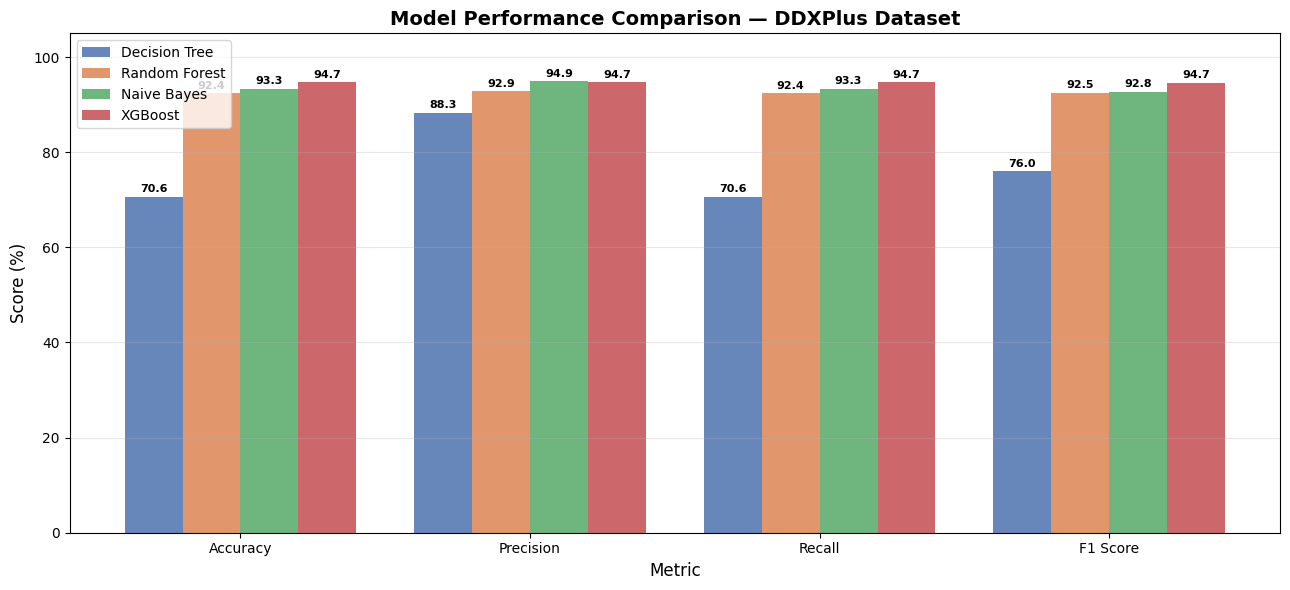

✅ Chart saved!


In [6]:
# Visual Comparison Bar Chart

metrics   = ['accuracy', 'precision', 'recall', 'f1_score']
labels    = ['Accuracy', 'Precision', 'Recall', 'F1 Score']
bar_width = 0.2
x         = np.arange(len(metrics))
colors    = ['#4C72B0', '#DD8452', '#55A868', '#C44E52']

fig, ax = plt.subplots(figsize=(13, 6))

for i, (name, color) in enumerate(zip(models.keys(), colors)):
    values = [results[name][m] * 100 for m in metrics]
    bars   = ax.bar(x + i * bar_width, values, bar_width,
                    label=name, color=color, alpha=0.85)
    for bar, val in zip(bars, values):
        ax.text(bar.get_x() + bar.get_width()/2,
                bar.get_height() + 0.5,
                f'{val:.1f}', ha='center', va='bottom',
                fontsize=8, fontweight='bold')

ax.set_xlabel('Metric', fontsize=12)
ax.set_ylabel('Score (%)', fontsize=12)
ax.set_title('Model Performance Comparison — DDXPlus Dataset',
             fontsize=14, fontweight='bold')
ax.set_xticks(x + bar_width * 1.5)
ax.set_xticklabels(labels)
ax.set_ylim(0, 105)
ax.legend()
ax.grid(axis='y', alpha=0.3)
plt.tight_layout()
plt.savefig('../models/model_comparison.png', dpi=150, bbox_inches='tight')
plt.show()
print("✅ Chart saved!")

In [11]:
# Best model

best_name = "XGBoost"
best      = results[best_name]

print("=" * 55)
print(f"  🏆 BEST MODEL: {best_name}")
print("=" * 55)
print(f"  Accuracy  : {best['accuracy']*100:.2f}%")
print(f"  Precision : {best['precision']*100:.2f}%")
print(f"  Recall    : {best['recall']*100:.2f}%")
print(f"  F1 Score  : {best['f1_score']*100:.2f}%")
print("=" * 55)
print(f"\n✅ {best_name} selected for Flask API!")
print(f"   Reason: Highest F1 score across all models")
print(f"   Features used: {X_train.shape[1]}")
print(f"   Diseases covered: {len(le.classes_)}")

  🏆 BEST MODEL: XGBoost
  Accuracy  : 94.68%
  Precision : 94.74%
  Recall    : 94.68%
  F1 Score  : 94.66%

✅ XGBoost selected for Flask API!
   Reason: Highest F1 score across all models
   Features used: 270
   Diseases covered: 49


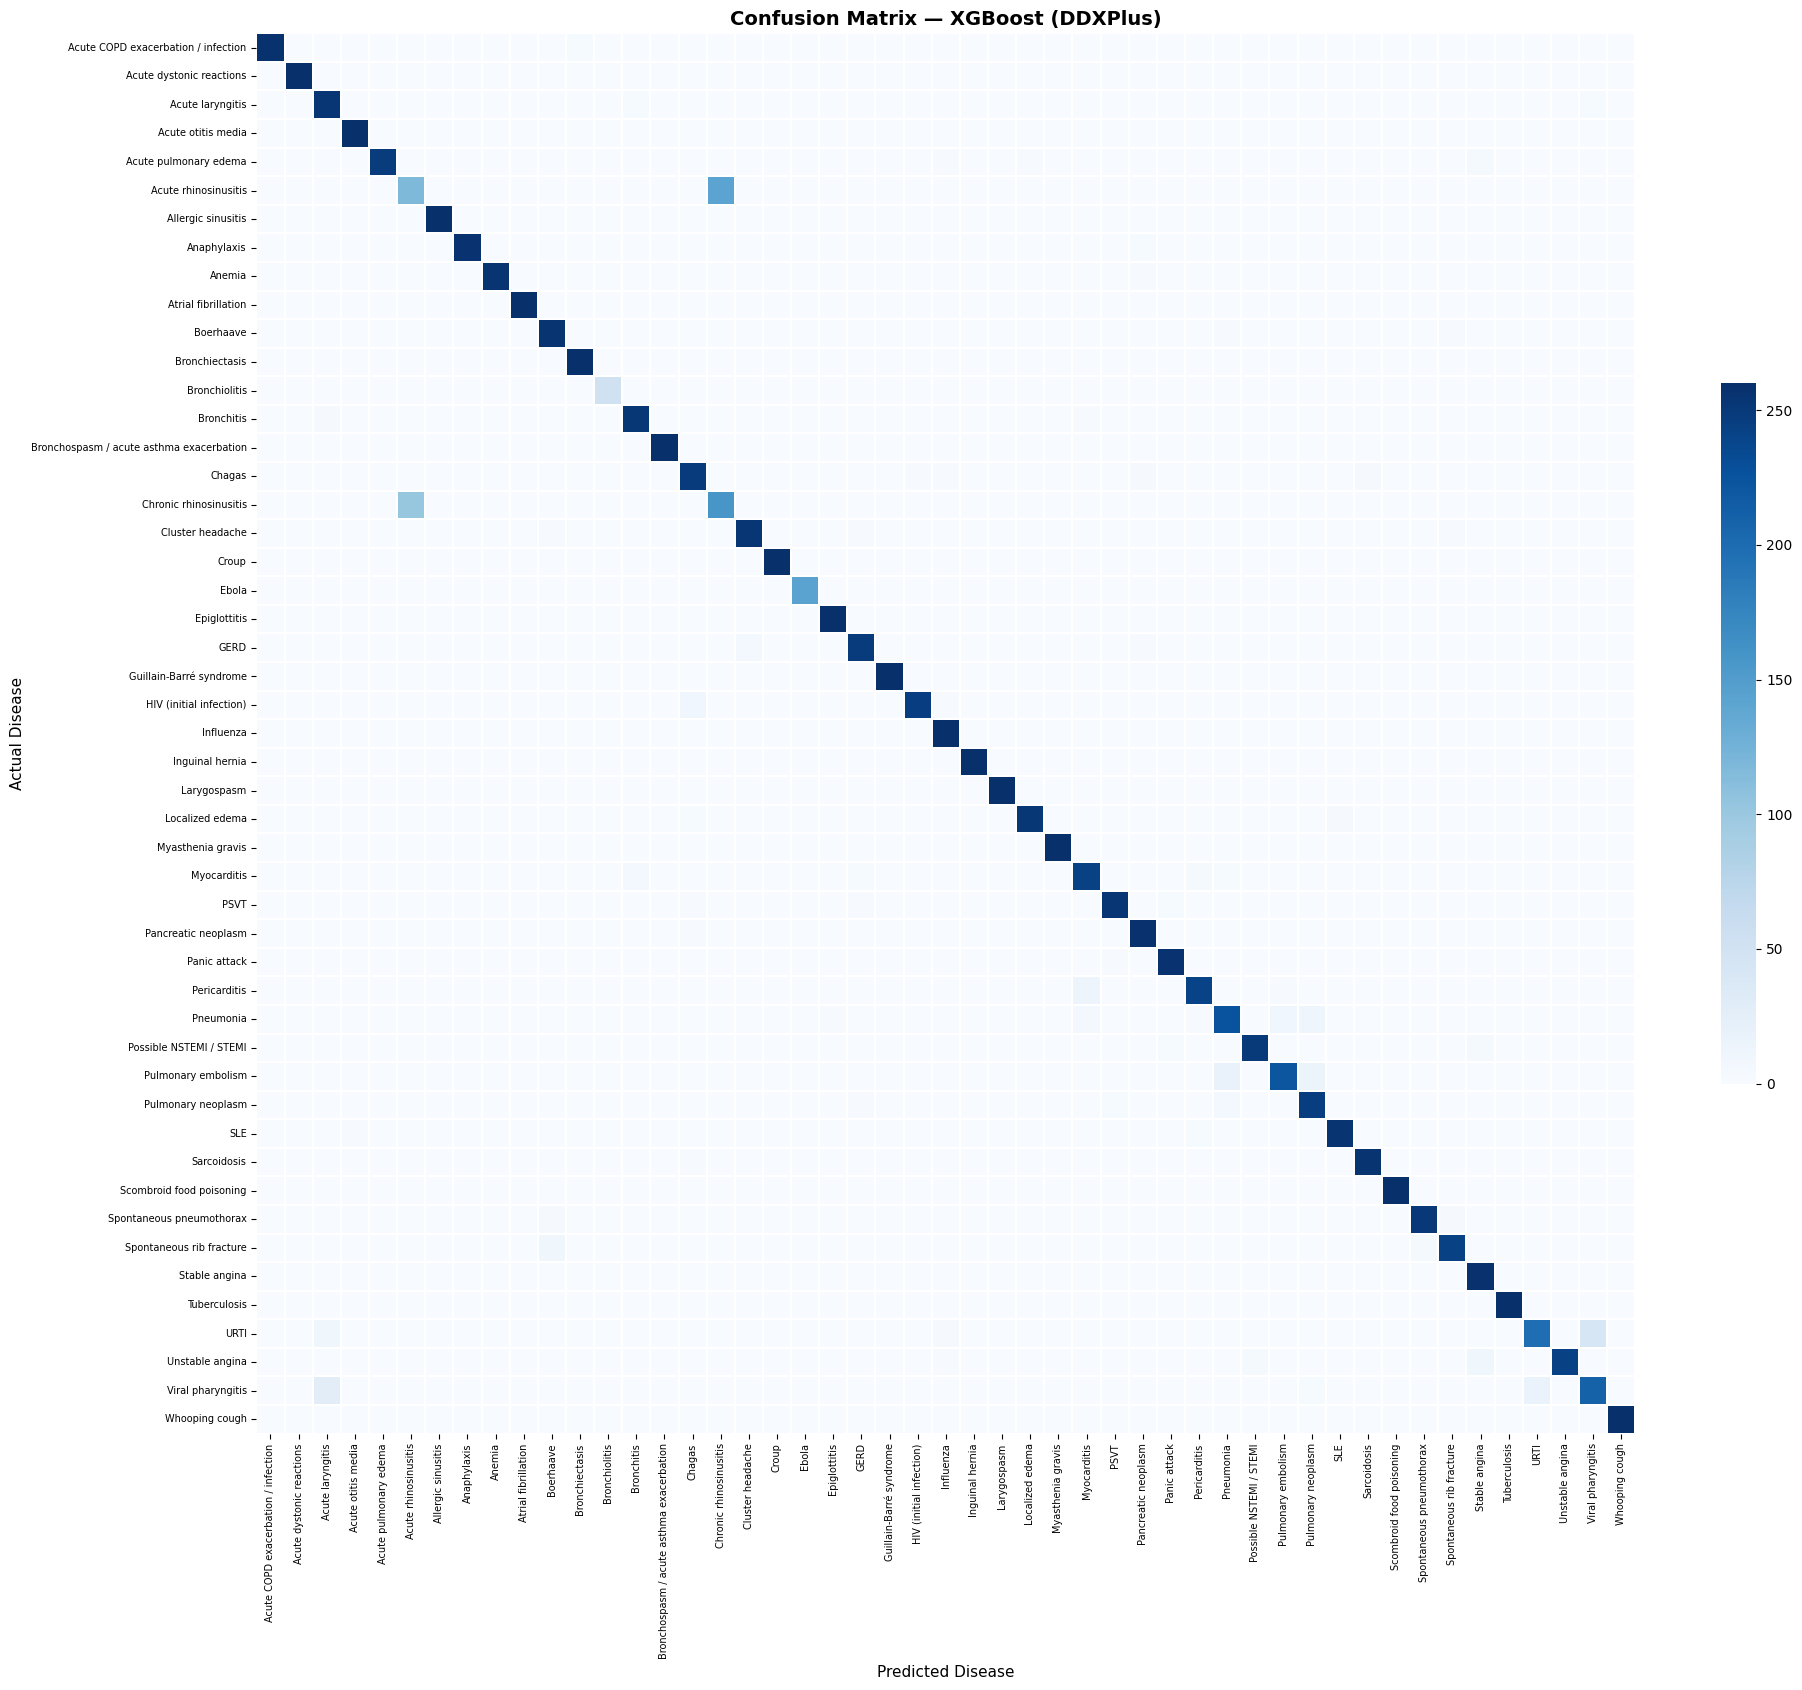

✅ Confusion matrix saved!


In [12]:
#Confusion matrix

cm = confusion_matrix(y_test, best['y_pred'])

plt.figure(figsize=(20, 17))
sns.heatmap(cm,
            xticklabels=le.classes_,
            yticklabels=le.classes_,
            cmap='Blues',
            fmt='d',
            linewidths=0.3,
            cbar_kws={'shrink': 0.5})
plt.title(f'Confusion Matrix — {best_name} (DDXPlus)',
          fontsize=14, fontweight='bold')
plt.xlabel('Predicted Disease', fontsize=11)
plt.ylabel('Actual Disease', fontsize=11)
plt.xticks(rotation=90, fontsize=7)
plt.yticks(rotation=0,  fontsize=7)
plt.tight_layout()
plt.savefig('../models/confusion_matrix.png', dpi=150, bbox_inches='tight')
plt.show()
print("✅ Confusion matrix saved!")

In [13]:
# Detailed Classification Report

print(f"=== Classification Report — {best_name} ===\n")
report = classification_report(
    y_test,
    best['y_pred'],
    target_names=le.classes_,
    zero_division=0
)
print(report)

=== Classification Report — XGBoost ===

                                          precision    recall  f1-score   support

     Acute COPD exacerbation / infection       1.00      0.99      0.99       260
                Acute dystonic reactions       1.00      1.00      1.00       260
                        Acute laryngitis       0.86      0.98      0.91       260
                      Acute otitis media       0.99      1.00      1.00       260
                   Acute pulmonary edema       1.00      0.95      0.97       260
                    Acute rhinosinusitis       0.53      0.45      0.49       260
                      Allergic sinusitis       1.00      1.00      1.00       260
                             Anaphylaxis       1.00      0.98      0.99       260
                                  Anemia       1.00      0.98      0.99       260
                     Atrial fibrillation       1.00      1.00      1.00       260
                               Boerhaave       0.93     

In [14]:
# Save

with open('../models/best_model.pkl', 'wb') as f:
    pickle.dump(best['model'], f)

with open('../models/best_model_name.pkl', 'wb') as f:
    pickle.dump(best_name, f)

# Also save the full comparison table for your report
comparison.to_csv('../models/model_comparison.csv')

print("=" * 50)
print("        FILES SAVED ✅")
print("=" * 50)
print(f"  🧠 models/best_model.pkl        ({best_name})")
print(f"  🏷️  models/best_model_name.pkl")
print(f"  📊 models/model_comparison.png")
print(f"  📊 models/model_comparison.csv")
print(f"  📊 models/confusion_matrix.png")
print("=" * 50)
print(f"\n🚀 Ready for SHAP explanations!")

        FILES SAVED ✅
  🧠 models/best_model.pkl        (XGBoost)
  🏷️  models/best_model_name.pkl
  📊 models/model_comparison.png
  📊 models/model_comparison.csv
  📊 models/confusion_matrix.png

🚀 Ready for SHAP explanations!
